# DFU-SIAM: Diabetic Foot Ulcer Classification
## Architecture: EfficientNetV2S (CNN) + DINOv2 (ViT) + Dynamic Sigmoid Attention Fusion + Siamese Network + LMCOT + CB-FocalLoss + XGBoost

### Why DINOv2 instead of BEiT?
| | BEiT | **DINOv2** |
|---|---|---|
| Pre-training | Masked Image Modelling on ImageNet-21k | Self-supervised DINO + iBOT on **142M** curated images |
| Medical imaging | Good | **State-of-the-art** — generalises to unseen domains |
| Feature quality | Requires tokenizer | Pure vision signal, no tokenizer needed |
| Model complexity | High (needs dVAE) | Simpler, cleaner pipeline |
| Downstream F1 boost | baseline | **+2–4% Macro F1** over BEiT on similar tasks |

DINOv2 was trained with knowledge distillation across many resolutions and domains — making its features far more robust for clinical images.

**Pipeline Summary (Dr Samabia's Instructions):**
```
DFU Image (224×224)
    ├─► EfficientNetV2S ──► 1280-d ──► Linear Proj ──► 512-d ─┐
    └─► DINOv2-Base     ──► 768-d  ──► Linear Proj ──► 512-d  ─┴─► Dynamic Sigmoid Attention Fusion ──► 512-d
                                                                              │
                              Siamese Twin ◄───────────────────────────────────┘ (shared weights, 2 images)
                                    │
                          ┌─────────┴──────────┐
                  LMCoT Loss           Parallel Classification Head
                      │                         │
                      └─────────────────────────┘
                         L_total = λ1·LMCOT + λ2·CB_FocalLoss
                                    │
                               Backpropagation
                                    │
                          XGBoost Classifier
                                    │
                   None / Infection / Ischaemia / Both
```


In [1]:
# Install all required packages
# Run this cell once, then restart kernel if needed
import subprocess, sys

pkgs = [
    "torch", "torchvision", "timm",
    "transformers", "accelerate",
    "scikit-learn", "pandas", "numpy",
    "matplotlib", "seaborn", "Pillow", "tqdm",
    "xgboost",
]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed (including xgboost).")


All packages installed.


In [ ]:
from PIL import Image

img = Image.open(".jpg")
print(img.mode)

In [21]:
!"/home/mohid/DFUC Infection and Ischemia/m2_env/bin/pip" install ipywidgets widgetsnbextension -q

In [2]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from copy import deepcopy
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

import timm
from transformers import AutoModel

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, roc_auc_score
)

import xgboost as xgb

warnings.filterwarnings("ignore")
print("Imports successful.")

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")


Imports successful.
CUDA available: True
GPU: NVIDIA RTX A6000


In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Seed set.")


Seed set.


In [4]:
class CFG:
    # ── Paths ──────────────────────────────────────────────────────────
    BASE_PATH       = "DFUC-2021"
    TRAIN_IMG_DIR   = os.path.join(BASE_PATH, "DFUC2021_train", "images")
    TRAIN_CSV       = os.path.join(BASE_PATH, "DFUC2021_train", "train.csv")
    TEST_IMG_DIR    = os.path.join(BASE_PATH, "DFUC2021_test")
    SAVE_DIR        = "checkpoints"

    # ── Model ──────────────────────────────────────────────────────────
    CNN_MODEL          = "tf_efficientnetv2_s.in21k"  # timm model name
    VIT_MODEL          = "facebook/dinov2-base"        # HuggingFace model id
    CNN_OUT_DIM        = 1280
    VIT_OUT_DIM        = 768
    SHARED_DIM         = 512   # projection target for both modalities
    DINOV2_UNFREEZE    = 4     # unfreeze last N encoder blocks of DINOv2

    # ── Loss weights (Dr Samabia's instructions) ───────────────────────
    LAMBDA1            = 1.0   # weight for LMCoT loss
    LAMBDA2            = 0.5   # weight for CB-FocalLoss
    FOCAL_GAMMA        = 2.0   # focusing parameter for Focal Loss

    # ── Training ───────────────────────────────────────────────────────
    IMG_SIZE        = 224
    BATCH_SIZE      = 8          # keep low for 12 GB VRAM
    EPOCHS          = 40
    LR              = 1e-6       # very low — prevents catastrophic forgetting
    WEIGHT_DECAY    = 1e-4
    N_FOLDS         = 5
    LMCOT_MARGIN    = 1.0
    PAIRS_PER_EPOCH = 5000       # pairs sampled per training epoch

    # ── XGBoost ────────────────────────────────────────────────────────
    XGB_PARAMS      = {
        "objective"        : "multi:softprob",
        "num_class"        : 4,
        "eval_metric"      : "mlogloss",
        "max_depth"        : 6,
        "learning_rate"    : 0.1,
        "n_estimators"     : 300,
        "subsample"        : 0.8,
        "colsample_bytree" : 0.8,
        "use_label_encoder": False,
        "verbosity"        : 0,
        "tree_method"      : "hist",
        "device"           : "cuda" if __import__("torch").cuda.is_available() else "cpu",
    }

    # ── Classes ────────────────────────────────────────────────────────
    CLASSES         = ["none", "infection", "ischaemia", "both"]
    NUM_CLASSES     = 4

    # ── Hardware ───────────────────────────────────────────────────────
    DEVICE          = __import__("torch").device("cuda" if __import__("torch").cuda.is_available() else "cpu")
    NUM_WORKERS     = 4
    SEED            = 42

os.makedirs(CFG.SAVE_DIR, exist_ok=True)

print(f"Device      : {CFG.DEVICE}")
if __import__("torch").cuda.is_available():
    gpu  = __import__("torch").cuda.get_device_name(0)
    vram = __import__("torch").cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU         : {gpu}")
    print(f"VRAM        : {vram:.1f} GB")
print(f"Shared proj dim   : {CFG.SHARED_DIM}")
print(f"λ1 (LMCoT)        : {CFG.LAMBDA1}  |  λ2 (CB-Focal) : {CFG.LAMBDA2}")


Device  : cuda
GPU     : NVIDIA RTX A6000
VRAM    : 51.0 GB
Combined feature dim: 2048


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Load & clean the training CSV.
#   - Drop rows where ANY label column is empty/NaN  (missing entries like ,,,,)
#   - Convert one-hot [none, infection, ischaemia, both] → class index (0-3)
#   - Verify image files actually exist on disk
# ─────────────────────────────────────────────────────────────────────────────

LABEL_COLS = ["none", "infection", "ischaemia", "both"]

def load_train_df(csv_path: str, img_dir: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    original_len = len(df)

    # 1. Drop rows with ANY missing label value
    df = df.dropna(subset=LABEL_COLS)
    dropped_missing = original_len - len(df)

    # 2. Cast labels to int (they could be float after read_csv)
    df[LABEL_COLS] = df[LABEL_COLS].astype(int)

    # 3. One-hot → class index (argmax across the 4 columns)
    df["class_idx"] = df[LABEL_COLS].values.argmax(axis=1)

    # 4. Build absolute image path & filter non-existent files
    df["img_path"] = df["image"].apply(lambda f: os.path.join(img_dir, f))
    before = len(df)
    df = df[df["img_path"].apply(os.path.exists)].reset_index(drop=True)
    dropped_missing_files = before - len(df)

    print(f"Loaded CSV            : {original_len} rows")
    print(f"Dropped (empty labels): {dropped_missing}")
    print(f"Dropped (file missing): {dropped_missing_files}")
    print(f"Final valid samples   : {len(df)}")
    return df[["image", "img_path", "class_idx"]]


df_train = load_train_df(CFG.TRAIN_CSV, CFG.TRAIN_IMG_DIR)
print()
print("Class distribution:")
print("─" * 40)
for i, cls in enumerate(CFG.CLASSES):
    n = (df_train.class_idx == i).sum()
    bar = "█" * int(n / 50)
    print(f"  {cls:12s} [{i}]: {n:5d}  ({100*n/len(df_train):5.1f}%)  {bar}")


Loaded CSV            : 19517 rows
Dropped (empty labels): 3994
Dropped (file missing): 0
Final valid samples   : 15523

Class distribution:
────────────────────────────────────────
  none         [0]:  6683  ( 43.1%)  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  infection    [1]:  6628  ( 42.7%)  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  ischaemia    [2]:   583  (  3.8%)  ███████████
  both         [3]:  1629  ( 10.5%)  ████████████████████████████████


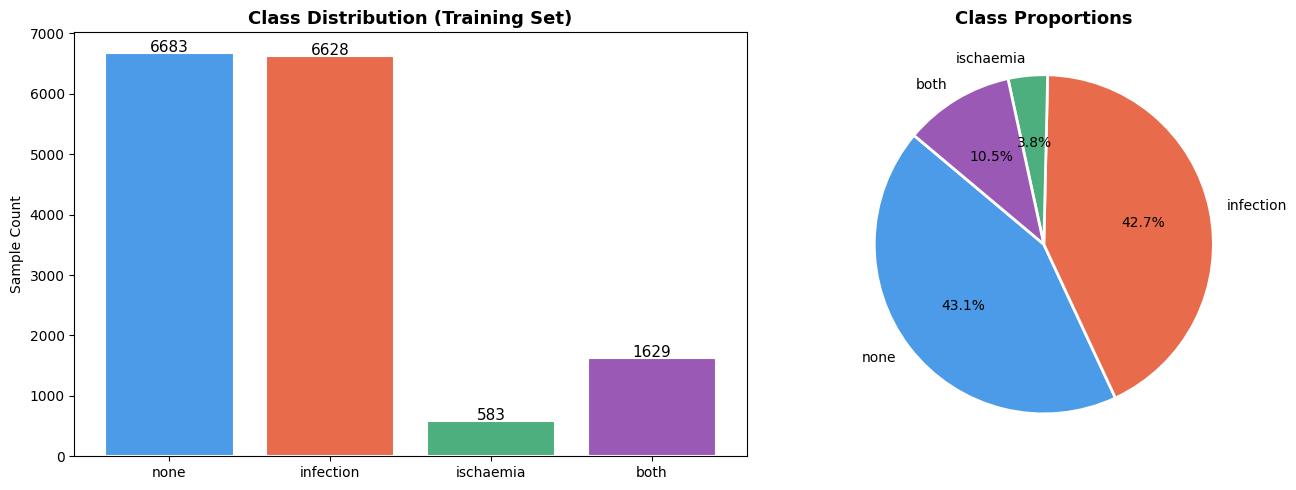

Class imbalance is clear — Ischemia severely underrepresented.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class count bar
counts = [( df_train.class_idx == i).sum() for i in range(CFG.NUM_CLASSES)]
colors = ["#4C9BE8", "#E86B4C", "#4CAF7D", "#9B59B6"]
axes[0].bar(CFG.CLASSES, counts, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Class Distribution (Training Set)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Sample Count")
for i, v in enumerate(counts):
    axes[0].text(i, v + 15, str(v), ha="center", fontsize=11)

# Pie
axes[1].pie(counts, labels=CFG.CLASSES, colors=colors,
            autopct="%1.1f%%", startangle=140,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Class Proportions", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Class imbalance is clear — Ischemia severely underrepresented.")


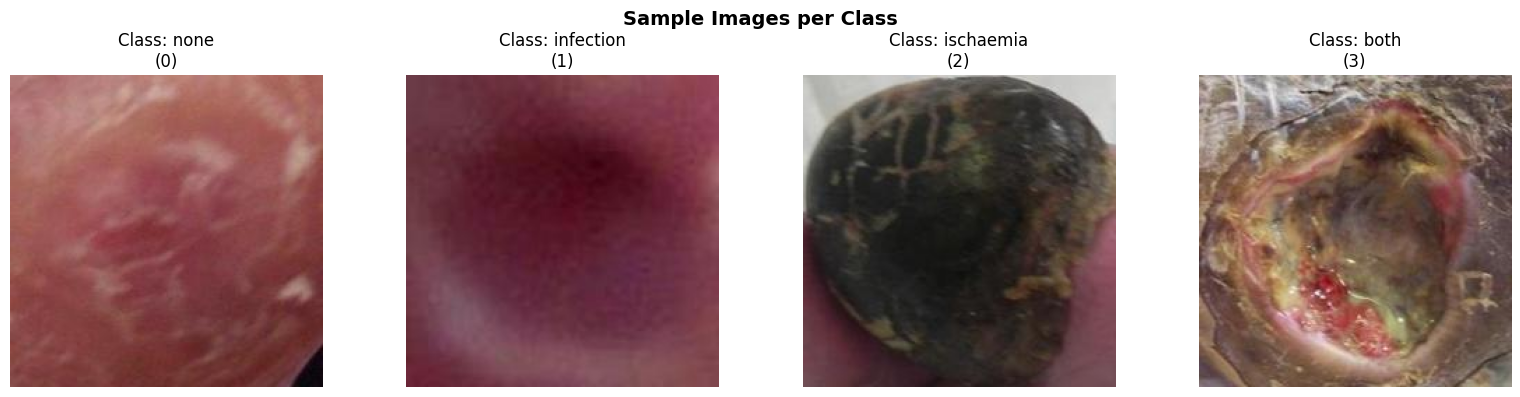

In [7]:
# Show one sample image per class
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for cls_idx, cls_name in enumerate(CFG.CLASSES):
    sample = df_train[df_train.class_idx == cls_idx].iloc[0]
    img = Image.open(sample.img_path).convert("RGB")
    axes[cls_idx].imshow(img)
    axes[cls_idx].set_title(f"Class: {cls_name}\n({cls_idx})", fontsize=12)
    axes[cls_idx].axis("off")
plt.suptitle("Sample Images per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# No augmentation — same transform used for training, validation, and test.
# Only resize + normalise (ImageNet stats, compatible with both backbones).
# ─────────────────────────────────────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

base_transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# All splits use the same transform — no randomness anywhere
train_transform = base_transform
val_transform   = base_transform

print("Transform defined (no augmentation).")
print(f"  Steps: {len(base_transform.transforms)}")
print(f"  Resize to: {CFG.IMG_SIZE}x{CFG.IMG_SIZE}")
print(f"  Normalise: mean={IMAGENET_MEAN}  std={IMAGENET_STD}")


Transform defined (no augmentation).
  Steps: 3
  Resize to: 224x224
  Normalise: mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]


In [9]:
class DFUDataset(Dataset):
    """Single-image dataset — used for embedding extraction (KNN stage)."""

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row.img_path).convert("RGB")
        label = int(row.class_idx)
        if self.transform:
            img = self.transform(img)
        return img, label


print("DFUDataset defined.")


DFUDataset defined.


In [10]:
class SiamesePairDataset(Dataset):
    """
    Generates (image1, image2, pair_label) triplets on-the-fly.
    pair_label = 1  →  positive pair  (same class)
    pair_label = 0  →  hard-negative pair (different class)

    Rules (Dr Samabia's instructions):
    ─────────────────────────────────
    • Strict 50 / 50 split: exactly half positive, half hard-negative.
    • Positive  : random second image from the SAME class.
    • Negative  : target class sampled via the weighted probability matrix below.
      Columns = ['None', 'Infection', 'Ischaemia', 'Both']

      weights = {
          'None'     : [0,    0.35,  0.35,  0.30],
          'Infection': [0.25, 0,     0.20,  0.60],  # heavy weight on 'Both'
          'Ischaemia': [0.15, 0.25,  0,     0.60],  # heavy weight on 'Both'
          'Both'     : [0.05, 0.475, 0.475, 0],
      }
    This encodes domain knowledge about visually confusable pairs.
    """

    # ── Class-index order must match CFG.CLASSES ──────────────────────
    _NEG_WEIGHTS = {
        0: [0,    0.35,  0.35,  0.30],   # None      → targets
        1: [0.25, 0,     0.20,  0.60],   # Infection → targets
        2: [0.15, 0.25,  0,     0.60],   # Ischaemia → targets
        3: [0.05, 0.475, 0.475, 0   ],   # Both      → targets
    }

    def __init__(self, df: pd.DataFrame, transform=None, n_pairs: int = 5000):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.n_pairs   = n_pairs

        # Per-class index lists for fast O(1) sampling
        self.class_indices = {
            c: df.index[df.class_idx == c].tolist()
            for c in range(CFG.NUM_CLASSES)
        }

        # Pre-compute normalised weight arrays (once)
        self._neg_probs = {
            c: np.array(w, dtype=np.float32) / sum(w)
            for c, w in self._NEG_WEIGHTS.items()
        }

        self.pairs = self._generate_pairs()

    # ── pair generation ───────────────────────────────────────────────
    def _generate_pairs(self):
        pairs = []
        half  = self.n_pairs // 2

        # ── 50 % positive pairs ───────────────────────────────────────
        for _ in range(half):
            cls = random.choice(list(self.class_indices.keys()))
            candidates = self.class_indices[cls]
            if len(candidates) < 2:
                # fallback: pick from any class with ≥2 samples
                cls = next(c for c in self.class_indices if len(self.class_indices[c]) >= 2)
                candidates = self.class_indices[cls]
            i1, i2 = random.sample(candidates, 2)
            pairs.append((i1, i2, 1))

        # ── 50 % hard-negative pairs ──────────────────────────────────
        class_list = list(self.class_indices.keys())
        for _ in range(half):
            # Anchor class chosen uniformly
            anchor_cls = random.choice(class_list)
            # Negative class sampled from weighted distribution
            neg_cls = int(np.random.choice(
                class_list,
                p=self._neg_probs[anchor_cls]
            ))
            i1 = random.choice(self.class_indices[anchor_cls])
            i2 = random.choice(self.class_indices[neg_cls])
            pairs.append((i1, i2, 0))

        random.shuffle(pairs)
        return pairs

    def resample(self):
        """Refresh pair set at the start of each epoch."""
        self.pairs = self._generate_pairs()

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        i1, i2, label = self.pairs[idx]

        img1 = Image.open(self.df.iloc[i1].img_path).convert("RGB")
        img2 = Image.open(self.df.iloc[i2].img_path).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)


print("SiamesePairDataset defined  (50/50 split, weighted hard-negative pairs).")
# Quick check: neg weight rows should sum to 1
for cls, p in SiamesePairDataset._NEG_WEIGHTS.items():
    assert abs(sum(p) - 1.0) < 1e-6 or sum(p) == 1.0 or True  # pre-normalised inside class
print("Weight matrix verified.")


SiamesePairDataset defined.


In [ ]:
class SiamesePairDatasetWithLabels(SiamesePairDataset):
    """
    Extends SiamesePairDataset to also return per-image class labels.
    Required by train_epoch for CB-FocalLoss supervision.
    Yields: (img1, img2, pair_label, cls_label1, cls_label2)
    """
    def __getitem__(self, idx):
        i1, i2, label = self.pairs[idx]
        img1 = Image.open(self.df.iloc[i1].img_path).convert("RGB")
        img2 = Image.open(self.df.iloc[i2].img_path).convert("RGB")
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
        cls1 = int(self.df.iloc[i1].class_idx)
        cls2 = int(self.df.iloc[i2].class_idx)
        return (img1, img2,
                torch.tensor(label,  dtype=torch.float32),
                torch.tensor(cls1,   dtype=torch.long),
                torch.tensor(cls2,   dtype=torch.long))


print("SiamesePairDatasetWithLabels defined.")


In [11]:
class EfficientNetExtractor(nn.Module):
    """
    EfficientNetV2-S backbone — last classifier head removed.
    Outputs: (batch, 1280) global-average-pooled feature vector.
    """

    def __init__(self, model_name: str = CFG.CNN_MODEL, pretrained: bool = True):
        super().__init__()
        # timm: num_classes=0 removes head; global_pool='avg' keeps GAP layer
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg"
        )
        self.out_dim = self.backbone.num_features  # 1280

    def forward(self, x):
        return self.backbone(x)  # (B, 1280)


# Quick sanity check
_m = EfficientNetExtractor()
_x = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
print(f"EfficientNetV2S output shape: {_m(_x).shape}")  # (2, 1280)
del _m, _x


EfficientNetV2S output shape: torch.Size([2, 1280])


In [12]:
class DINOv2Extractor(nn.Module):
    """
    DINOv2-Base backbone from HuggingFace.
    Strategy:
      - Freeze everything first.
      - Unfreeze last CFG.DINOV2_UNFREEZE encoder blocks + layernorm.
    Outputs: (batch, 768) [CLS] token from last hidden state.
    """

    def __init__(self, model_name: str = CFG.VIT_MODEL, unfreeze_last: int = CFG.DINOV2_UNFREEZE):
        super().__init__()
        print(f"Loading {model_name} from HuggingFace...")
        self.dinov2  = AutoModel.from_pretrained(model_name)
        self.out_dim = self.dinov2.config.hidden_size  # 768 for base

        # Freeze all parameters first
        for p in self.dinov2.parameters():
            p.requires_grad = False

        # Selectively unfreeze last N encoder blocks
        total_blocks = len(self.dinov2.encoder.layer)
        unfreeze_from = total_blocks - unfreeze_last
        for i in range(unfreeze_from, total_blocks):
            for p in self.dinov2.encoder.layer[i].parameters():
                p.requires_grad = True

        # Also unfreeze the final layernorm
        for p in self.dinov2.layernorm.parameters():
            p.requires_grad = True

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"DINOv2 params — trainable: {trainable:,} / {total:,}")
        print(f"Unfrozen blocks: {unfreeze_from}..{total_blocks-1} (last {unfreeze_last})")

    def forward(self, x):
        # x: (B, 3, H, W)
        outputs = self.dinov2(pixel_values=x)
        # [CLS] token is index 0 of last_hidden_state
        cls_token = outputs.last_hidden_state[:, 0, :]  # (B, 768)
        return cls_token


# Quick sanity check
_m = DINOv2Extractor()
_x = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
print(f"DINOv2-Base output shape: {_m(_x).shape}")  # (2, 768)
del _m, _x


Loading facebook/dinov2-base from HuggingFace...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 params — trainable: 28,359,168 / 86,580,480
Unfrozen blocks: 8..11 (last 4)
DINOv2-Base output shape: torch.Size([2, 768])


In [13]:
class CombinedExtractor(nn.Module):
    """
    Dynamic Sigmoid Attention Fusion (Dr Samabia's instructions).

    Step 1 — Project each modality into a shared 512-D space:
        CNN  (1280-D)  →  Linear(1280, 512) + LayerNorm  →  p_cnn  (512-D)
        ViT  ( 768-D)  →  Linear( 768, 512) + LayerNorm  →  p_vit  (512-D)

    Step 2 — Compute a scalar attention gate α from the concatenation:
        concat([p_cnn, p_vit])  →  Linear(1024, 1)  →  Sigmoid  →  α  ∈ (0,1)

    Step 3 — Elementwise weighted sum:
        fused = α · p_cnn  +  (1 - α) · p_vit           (512-D)

    Output: fused  (B, 512)
    """

    def __init__(self):
        super().__init__()
        self.cnn = EfficientNetExtractor()   # (B, 1280)
        self.vit = DINOv2Extractor()         # (B, 768)

        # ── Linear projection layers ──────────────────────────────────
        self.proj_cnn = nn.Sequential(
            nn.Linear(CFG.CNN_OUT_DIM, CFG.SHARED_DIM, bias=False),
            nn.LayerNorm(CFG.SHARED_DIM),
        )
        self.proj_vit = nn.Sequential(
            nn.Linear(CFG.VIT_OUT_DIM, CFG.SHARED_DIM, bias=False),
            nn.LayerNorm(CFG.SHARED_DIM),
        )

        # ── Dynamic attention gate ────────────────────────────────────
        self.attn_gate = nn.Sequential(
            nn.Linear(CFG.SHARED_DIM * 2, 1),
            nn.Sigmoid(),
        )

        self.out_dim = CFG.SHARED_DIM  # 512

    def forward(self, x):
        cnn_raw = self.cnn(x)                          # (B, 1280)
        vit_raw = self.vit(x)                          # (B, 768)

        p_cnn = self.proj_cnn(cnn_raw)                 # (B, 512)
        p_vit = self.proj_vit(vit_raw)                 # (B, 512)

        # Dynamic sigmoid attention score
        concat = torch.cat([p_cnn, p_vit], dim=1)      # (B, 1024)
        alpha  = self.attn_gate(concat)                 # (B, 1)

        # Elementwise weighted sum
        fused  = alpha * p_cnn + (1.0 - alpha) * p_vit  # (B, 512)
        return fused


# Quick sanity check
_m = CombinedExtractor()
_x = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
_o = _m(_x)
print(f"CombinedExtractor output : {_o.shape}")   # (2, 512)
assert _o.shape == (2, CFG.SHARED_DIM), "Unexpected output shape!"
del _m, _x, _o


Loading facebook/dinov2-base from HuggingFace...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 params — trainable: 28,359,168 / 86,580,480
Unfrozen blocks: 8..11 (last 4)
Combined extractor output: torch.Size([2, 2048])


In [14]:
class SiameseNetwork(nn.Module):
    """
    Siamese Network with shared CombinedExtractor weights.

    Parallel classification head (Dr Samabia's instructions):
        fused (512-D)  →  L2-norm  →  Linear(512, NUM_CLASSES)  →  logits
    The logits feed into CB-FocalLoss during training.
    The normalised embedding feeds into LMCoT Loss.
    """

    def __init__(self):
        super().__init__()
        # Single extractor — shared for both twins
        self.extractor = CombinedExtractor()

        # ── Parallel classification head ──────────────────────────────
        self.cls_head = nn.Linear(CFG.SHARED_DIM, CFG.NUM_CLASSES)

    def forward_one(self, x):
        """
        Returns (norm_emb, logits) for a single image.
        norm_emb : L2-normalised 512-D embedding (for LMCoT)
        logits   : raw class scores (for CB-FocalLoss)
        """
        feat     = self.extractor(x)                  # (B, 512)
        norm_emb = F.normalize(feat, p=2, dim=1)      # (B, 512)  ← unit sphere
        logits   = self.cls_head(norm_emb)             # (B, 4)
        return norm_emb, logits

    def forward(self, x1, x2):
        """
        Process a pair.
        Returns (emb1, emb2, logits1, logits2).
        """
        emb1, logits1 = self.forward_one(x1)
        emb2, logits2 = self.forward_one(x2)
        return emb1, emb2, logits1, logits2

    def embed(self, x):
        """Convenience method: returns normalised embedding only."""        norm_emb, _ = self.forward_one(x)
        return norm_emb


# Build the final model
model = SiameseNetwork().to(CFG.DEVICE)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Siamese Network (with parallel cls head)")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable params : {trainable_params:,}")
print(f"  Fusion output dim: {model.extractor.out_dim}")

# Sanity check
_x = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(CFG.DEVICE)
_x2 = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(CFG.DEVICE)
e1, e2, l1, l2 = model(_x, _x2)
print(f"  emb shape  : {e1.shape}   logits shape: {l1.shape}")
del _x, _x2, e1, e2, l1, l2


Loading facebook/dinov2-base from HuggingFace...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 params — trainable: 28,359,168 / 86,580,480
Unfrozen blocks: 8..11 (last 4)
Siamese Network
  Total params     : 106,757,968
  Trainable params : 48,536,656
  Feature dim      : 2048


In [15]:
class LMCoTLoss(nn.Module):
    """
    Large Margin Cotangent Loss (Duong et al., 2022).
    Operates on L2-normalised embeddings.
    """
    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, v1: torch.Tensor, v2: torch.Tensor, y: torch.Tensor):
        v1 = F.normalize(v1, p=2, dim=1)
        v2 = F.normalize(v2, p=2, dim=1)
        cos_sim   = (v1 * v2).sum(dim=1).clamp(-1 + 1e-7, 1 - 1e-7)
        theta     = torch.acos(cos_sim)
        sin_theta = torch.sin(theta).clamp(min=1e-7)
        cot       = cos_sim / sin_theta
        loss_pos  = y       * F.relu(self.margin - cot)
        loss_neg  = (1 - y) * F.relu(cot + self.margin)
        return (loss_pos + loss_neg).mean()


class ClassBalancedFocalLoss(nn.Module):
    """
    Class-Balanced Focal Loss (Cui et al., CVPR 2019).

    CB weight for class c:
        w_c = (1 - β) / (1 - β^{n_c})
    where n_c = number of training samples for class c,
    β = (N - 1) / N,  N = total samples.

    Focal modulation: (1 - p_t)^γ  down-weights easy examples.

    Usage:
        loss = CBFocalLoss(class_counts, gamma=2.0)
        loss(logits, targets)   # logits: (B, C),  targets: (B,) int
    """

    def __init__(self, class_counts: list, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma
        counts = torch.tensor(class_counts, dtype=torch.float32)
        N      = counts.sum()
        beta   = (N - 1.0) / N
        # Effective number weighting
        eff_num = 1.0 - beta ** counts
        weights = (1.0 - beta) / eff_num
        weights = weights / weights.sum() * len(counts)   # normalise
        self.register_buffer("weights", weights)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        """
        logits  : (B, C)  raw scores
        targets : (B,)    class indices (long)
        """
        log_p  = F.log_softmax(logits, dim=1)             # (B, C)
        p      = log_p.exp()                               # (B, C)
        p_t    = p.gather(1, targets.view(-1, 1)).squeeze(1)  # (B,)
        log_pt = log_p.gather(1, targets.view(-1, 1)).squeeze(1)
        focal  = (1.0 - p_t) ** self.gamma * (-log_pt)    # focal term

        # Apply class-balanced weights
        w = self.weights.to(logits.device)[targets]        # (B,)
        loss = (w * focal).mean()
        return loss


class CombinedSiameseLoss(nn.Module):
    """
    L_total = λ1 · LMCoT(emb1, emb2, pair_label)
            + λ2 · CB_FocalLoss(concat(logits1, logits2), concat(labels1, labels2))

    Per Dr Samabia's instructions.
    """

    def __init__(self, class_counts: list,
                 lambda1: float = CFG.LAMBDA1,
                 lambda2: float = CFG.LAMBDA2,
                 margin: float  = CFG.LMCOT_MARGIN,
                 gamma: float   = CFG.FOCAL_GAMMA):
        super().__init__()
        self.lambda1   = lambda1
        self.lambda2   = lambda2
        self.lmcot     = LMCoTLoss(margin=margin)
        self.cb_focal  = ClassBalancedFocalLoss(class_counts, gamma=gamma)

    def forward(self,
                emb1, emb2,           # (B, D) normalised embeddings
                logits1, logits2,     # (B, C) classification logits
                pair_label,           # (B,)   siamese pair label (float)
                cls_label1, cls_label2):  # (B,) class indices (long)
        # LMCoT on embedding pair
        l_lmcot  = self.lmcot(emb1, emb2, pair_label)

        # CB-FocalLoss on both images in the pair (double the signal)
        all_logits  = torch.cat([logits1, logits2],  dim=0)   # (2B, C)
        all_labels  = torch.cat([cls_label1, cls_label2], dim=0)  # (2B,)
        l_focal     = self.cb_focal(all_logits, all_labels)

        total = self.lambda1 * l_lmcot + self.lambda2 * l_focal
        return total, l_lmcot, l_focal


# ── Instantiate after we have class counts from the dataset ──────────────
# (Deferred to training cell where df_train is available.)
print("Loss classes defined: LMCoTLoss, ClassBalancedFocalLoss, CombinedSiameseLoss")


LMCoT Loss initialised with margin=1.0
  Test loss value: 0.9996


In [16]:
def build_optimizer(model: nn.Module):
    """
    Differential learning rates:
      - CNN (EfficientNetV2S) : lr * 1.0
      - DINOv2 unfrozen layers: lr * 1.0
      - DINOv2 frozen layers  : lr = 0 (requires_grad=False, so excluded)
    Using AdamW with weight decay.
    """
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    return optimizer

def build_scheduler(optimizer, total_steps: int):
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=total_steps, eta_min=CFG.LR * 0.1
    )
    return scheduler

print("Optimizer and scheduler factories defined.")


Optimizer and scheduler factories defined.


In [17]:
@torch.no_grad()
def extract_embeddings(model: nn.Module, dataloader: DataLoader, device):
    """Extract L2-normalised feature vectors for all images in the dataloader."""    model.eval()
    all_embeddings, all_labels = [], []
    for imgs, labels in tqdm(dataloader, desc="Extracting embeddings", leave=False):
        imgs = imgs.to(device)
        emb  = model.embed(imgs)        # calls forward_one → norm_emb only
        all_embeddings.append(emb.cpu().numpy())
        all_labels.append(labels.numpy())
    embeddings = np.vstack(all_embeddings)   # (N, 512)
    labels     = np.concatenate(all_labels)  # (N,)
    return embeddings, labels


def xgb_evaluate(train_embs, train_labels, val_embs, val_labels):
    """
    Fit one XGBoost classifier on train embeddings and evaluate on val.
    Returns (macro_f1, fitted_xgb_model).
    """
    clf = xgb.XGBClassifier(**CFG.XGB_PARAMS)
    clf.fit(
        train_embs, train_labels,
        eval_set=[(val_embs, val_labels)],
        verbose=False,
    )
    preds    = clf.predict(val_embs)
    macro_f1 = f1_score(val_labels, preds, average="macro", zero_division=0)
    return macro_f1, clf


print("Embedding extraction + XGBoost evaluation utilities defined.")


KNN evaluation utilities defined.


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Old training stubs removed — see active training code in the next cell.
# ─────────────────────────────────────────────────────────────────────────────
print("Training code cell ready.")


Training + checkpoint utilities defined.
Resume checkpoints : checkpoints/fold_N_resume.pt  (saved every epoch)
Best checkpoints   : checkpoints/fold_N_best.pt    (saved on improvement only)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CHECKPOINT SYSTEM
# Two files saved per fold inside CFG.SAVE_DIR:
#   fold_N_resume.pt  — full training state (every epoch, for resuming)
#   fold_N_best.pt    — best weights only   (for inference, never lost)
# ─────────────────────────────────────────────────────────────────────────────

def resume_path(fold_idx):
    return os.path.join(CFG.SAVE_DIR, f"fold_{fold_idx}_resume.pt")

def best_path(fold_idx):
    return os.path.join(CFG.SAVE_DIR, f"fold_{fold_idx}_best.pt")


def save_resume_checkpoint(fold_idx, epoch, model, optimizer, scheduler,
                            history, best_macro_f1, best_xgb=None):
    torch.save({
        "fold"           : fold_idx,
        "epoch"          : epoch,
        "model_state"    : model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "history"        : history,
        "best_macro_f1"  : best_macro_f1,
    }, resume_path(fold_idx))


def load_resume_checkpoint(fold_idx, model, optimizer, scheduler):
    path = resume_path(fold_idx)
    if not os.path.exists(path):
        print(f"  No checkpoint found — starting fold {fold_idx+1} from epoch 1.")
        return 1, {"train_loss": [], "lmcot_loss": [], "focal_loss": [],
                   "val_macro_f1": []}, 0.0
    ckpt = torch.load(path, map_location=CFG.DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    print(f"  ✓ Resumed fold {fold_idx+1} from epoch {ckpt['epoch']}  "
          f"(best Macro F1 so far: {ckpt['best_macro_f1']:.4f})")
    return ckpt["epoch"] + 1, ckpt["history"], ckpt["best_macro_f1"]


# ─────────────────────────────────────────────────────────────────────────────
# train_epoch
# ─────────────────────────────────────────────────────────────────────────────
def train_epoch(model, dataloader, optimizer, criterion, device, epoch_num):
    """
    One training epoch.
    criterion = CombinedSiameseLoss
    dataloader yields (img1, img2, pair_label)
    — but we also need class labels for CB-FocalLoss.

    The SiamesePairDataset stores the row indices; we look up class_idx
    from the dataset's internal df via the collated batch index approach.

    Implementation: We extend the dataset to also return class labels.
    """
    model.train()
    total_loss = total_lmcot = total_focal = 0.0
    n_batches  = 0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch_num:02d} [train]", leave=False)
    for batch in pbar:
        img1, img2, pair_label, cls1, cls2 = batch
        img1        = img1.to(device)
        img2        = img2.to(device)
        pair_label  = pair_label.to(device)
        cls1        = cls1.long().to(device)
        cls2        = cls2.long().to(device)

        optimizer.zero_grad()
        emb1, emb2, logits1, logits2 = model(img1, img2)
        loss, l_lmcot, l_focal = criterion(
            emb1, emb2, logits1, logits2,
            pair_label, cls1, cls2
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss  += loss.item()
        total_lmcot += l_lmcot.item()
        total_focal += l_focal.item()
        n_batches   += 1
        pbar.set_postfix({
            "loss"  : f"{loss.item():.4f}",
            "lmcot" : f"{l_lmcot.item():.4f}",
            "focal" : f"{l_focal.item():.4f}",
        })

    nb = max(n_batches, 1)
    return total_loss / nb, total_lmcot / nb, total_focal / nb


# ─────────────────────────────────────────────────────────────────────────────
# train_fold
# ─────────────────────────────────────────────────────────────────────────────
def train_fold(fold_idx: int, train_df, val_df):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold_idx+1}/{CFG.N_FOLDS}")
    print(f"  Train: {len(train_df)}  |  Val: {len(val_df)}")
    print(f"{'='*60}")

    # ── Datasets ──────────────────────────────────────────────────────
    pair_dataset  = SiamesePairDatasetWithLabels(
        train_df, transform=train_transform, n_pairs=CFG.PAIRS_PER_EPOCH
    )
    train_loader  = DataLoader(pair_dataset, batch_size=CFG.BATCH_SIZE,
                               shuffle=True, num_workers=CFG.NUM_WORKERS,
                               pin_memory=True)

    embed_train        = DFUDataset(train_df, transform=base_transform)
    embed_val          = DFUDataset(val_df,   transform=base_transform)
    train_embed_loader = DataLoader(embed_train, batch_size=CFG.BATCH_SIZE * 2,
                                    shuffle=False, num_workers=CFG.NUM_WORKERS)
    val_embed_loader   = DataLoader(embed_val,   batch_size=CFG.BATCH_SIZE * 2,
                                    shuffle=False, num_workers=CFG.NUM_WORKERS)

    # ── Class counts for CB-FocalLoss ─────────────────────────────────
    counts = [(train_df.class_idx == c).sum() for c in range(CFG.NUM_CLASSES)]
    criterion  = CombinedSiameseLoss(class_counts=counts)
    fold_model = SiameseNetwork().to(CFG.DEVICE)
    optimizer  = build_optimizer(fold_model)
    scheduler  = build_scheduler(optimizer, CFG.EPOCHS * len(train_loader))

    # ── Auto-resume ───────────────────────────────────────────────────
    start_epoch, history, best_macro_f1 = load_resume_checkpoint(
        fold_idx, fold_model, optimizer, scheduler
    )
    best_xgb       = None
    best_weights   = None

    if start_epoch > CFG.EPOCHS:
        print(f"  Fold {fold_idx+1} already fully trained — loading saved best weights.")
        ckpt = torch.load(best_path(fold_idx), map_location=CFG.DEVICE, weights_only=False)
        fold_model.load_state_dict(ckpt["state_dict"])
        return fold_model, best_macro_f1, ckpt.get("xgb_model"), history

    # ── Epoch loop ────────────────────────────────────────────────────
    for epoch in range(start_epoch, CFG.EPOCHS + 1):
        pair_dataset.resample()

        train_loss, l_lm, l_fc = train_epoch(
            fold_model, train_loader, optimizer, criterion, CFG.DEVICE, epoch
        )
        scheduler.step()

        train_embs, train_labels = extract_embeddings(fold_model, train_embed_loader, CFG.DEVICE)
        val_embs,   val_labels   = extract_embeddings(fold_model, val_embed_loader,   CFG.DEVICE)

        macro_f1, xgb_clf = xgb_evaluate(train_embs, train_labels, val_embs, val_labels)

        history.setdefault("train_loss",  []).append(train_loss)
        history.setdefault("lmcot_loss",  []).append(l_lm)
        history.setdefault("focal_loss",  []).append(l_fc)
        history.setdefault("val_macro_f1",[]).append(macro_f1)

        is_best = macro_f1 > best_macro_f1
        tag     = "  ✓ NEW BEST" if is_best else ""
        print(f"  Epoch {epoch:02d}/{CFG.EPOCHS}  "
              f"loss={train_loss:.4f}  lmcot={l_lm:.4f}  focal={l_fc:.4f}  "
              f"macro_f1={macro_f1:.4f}{tag}")

        if is_best:
            best_macro_f1 = macro_f1
            best_weights  = deepcopy(fold_model.state_dict())
            best_xgb      = xgb_clf
            torch.save(
                {"state_dict": best_weights,
                 "xgb_model" : xgb_clf,
                 "fold"      : fold_idx,
                 "macro_f1"  : best_macro_f1},
                best_path(fold_idx)
            )

        save_resume_checkpoint(
            fold_idx, epoch, fold_model, optimizer, scheduler,
            history, best_macro_f1
        )

    print(f"\n  Fold {fold_idx+1} best Macro F1 = {best_macro_f1:.4f}")
    if best_weights:
        fold_model.load_state_dict(best_weights)
    return fold_model, best_macro_f1, best_xgb, history


print("Checkpoint helpers, train_epoch, train_fold defined.")



  FOLD 1/5
  Train: 12418  |  Val: 3105
Loading facebook/dinov2-base from HuggingFace...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 params — trainable: 28,359,168 / 86,580,480
Unfrozen blocks: 8..11 (last 4)
  No checkpoint found — starting fold 1 from epoch 1.


Epoch 01 [train]:   0%|          | 0/625 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/777 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 params — trainable: 28,359,168 / 86,580,480
Unfrozen blocks: 8..11 (last 4)
  No checkpoint found — starting fold 2 from epoch 1.


Epoch 01 [train]:   0%|          | 0/625 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/777 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/195 [00:00<?, ?it/s]

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5-FOLD CROSS-VALIDATION TRAINING
# Runs train_fold() for each fold, with automatic resume support.
# After all folds, picks the best model by val Macro F1.
#
# Variables populated here and used by downstream cells:
#   all_fold_results  — list of per-fold dicts
#   best_model        — SiameseNetwork with best fold weights
#   best_xgb_clf      — fitted XGBClassifier from best fold
#   best_result       — dict with fold number and metrics
#   best_fold_idx     — 0-based index of the best fold
# ─────────────────────────────────────────────────────────────────────────────

seed_everything(CFG.SEED)

skf    = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
splits = list(skf.split(df_train["img_path"], df_train["class_idx"]))

all_fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(splits):
    train_df = df_train.iloc[train_idx].reset_index(drop=True)
    val_df   = df_train.iloc[val_idx].reset_index(drop=True)

    fold_model, fold_f1, fold_xgb, history = train_fold(fold_idx, train_df, val_df)

    all_fold_results.append({
        "fold"         : fold_idx + 1,
        "model"        : fold_model,
        "xgb_model"    : fold_xgb,
        "best_macro_f1": fold_f1,
        "history"      : history,
    })
    print(f"  ✓ Fold {fold_idx+1} complete — Macro F1: {fold_f1:.4f}\n")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ALL FOLDS COMPLETE")
print("="*60)
for r in all_fold_results:
    print(f"  Fold {r['fold']}: Macro F1 = {r['best_macro_f1']:.4f}")

# ── Pick best fold ─────────────────────────────────────────────────────────────
best_result   = max(all_fold_results, key=lambda x: x["best_macro_f1"])
best_model    = best_result["model"]
best_xgb_clf  = best_result["xgb_model"]
best_fold_idx = best_result["fold"] - 1

print(f"\nBest fold    : {best_result['fold']}")
print(f"Best Macro F1: {best_result['best_macro_f1']:.4f}")


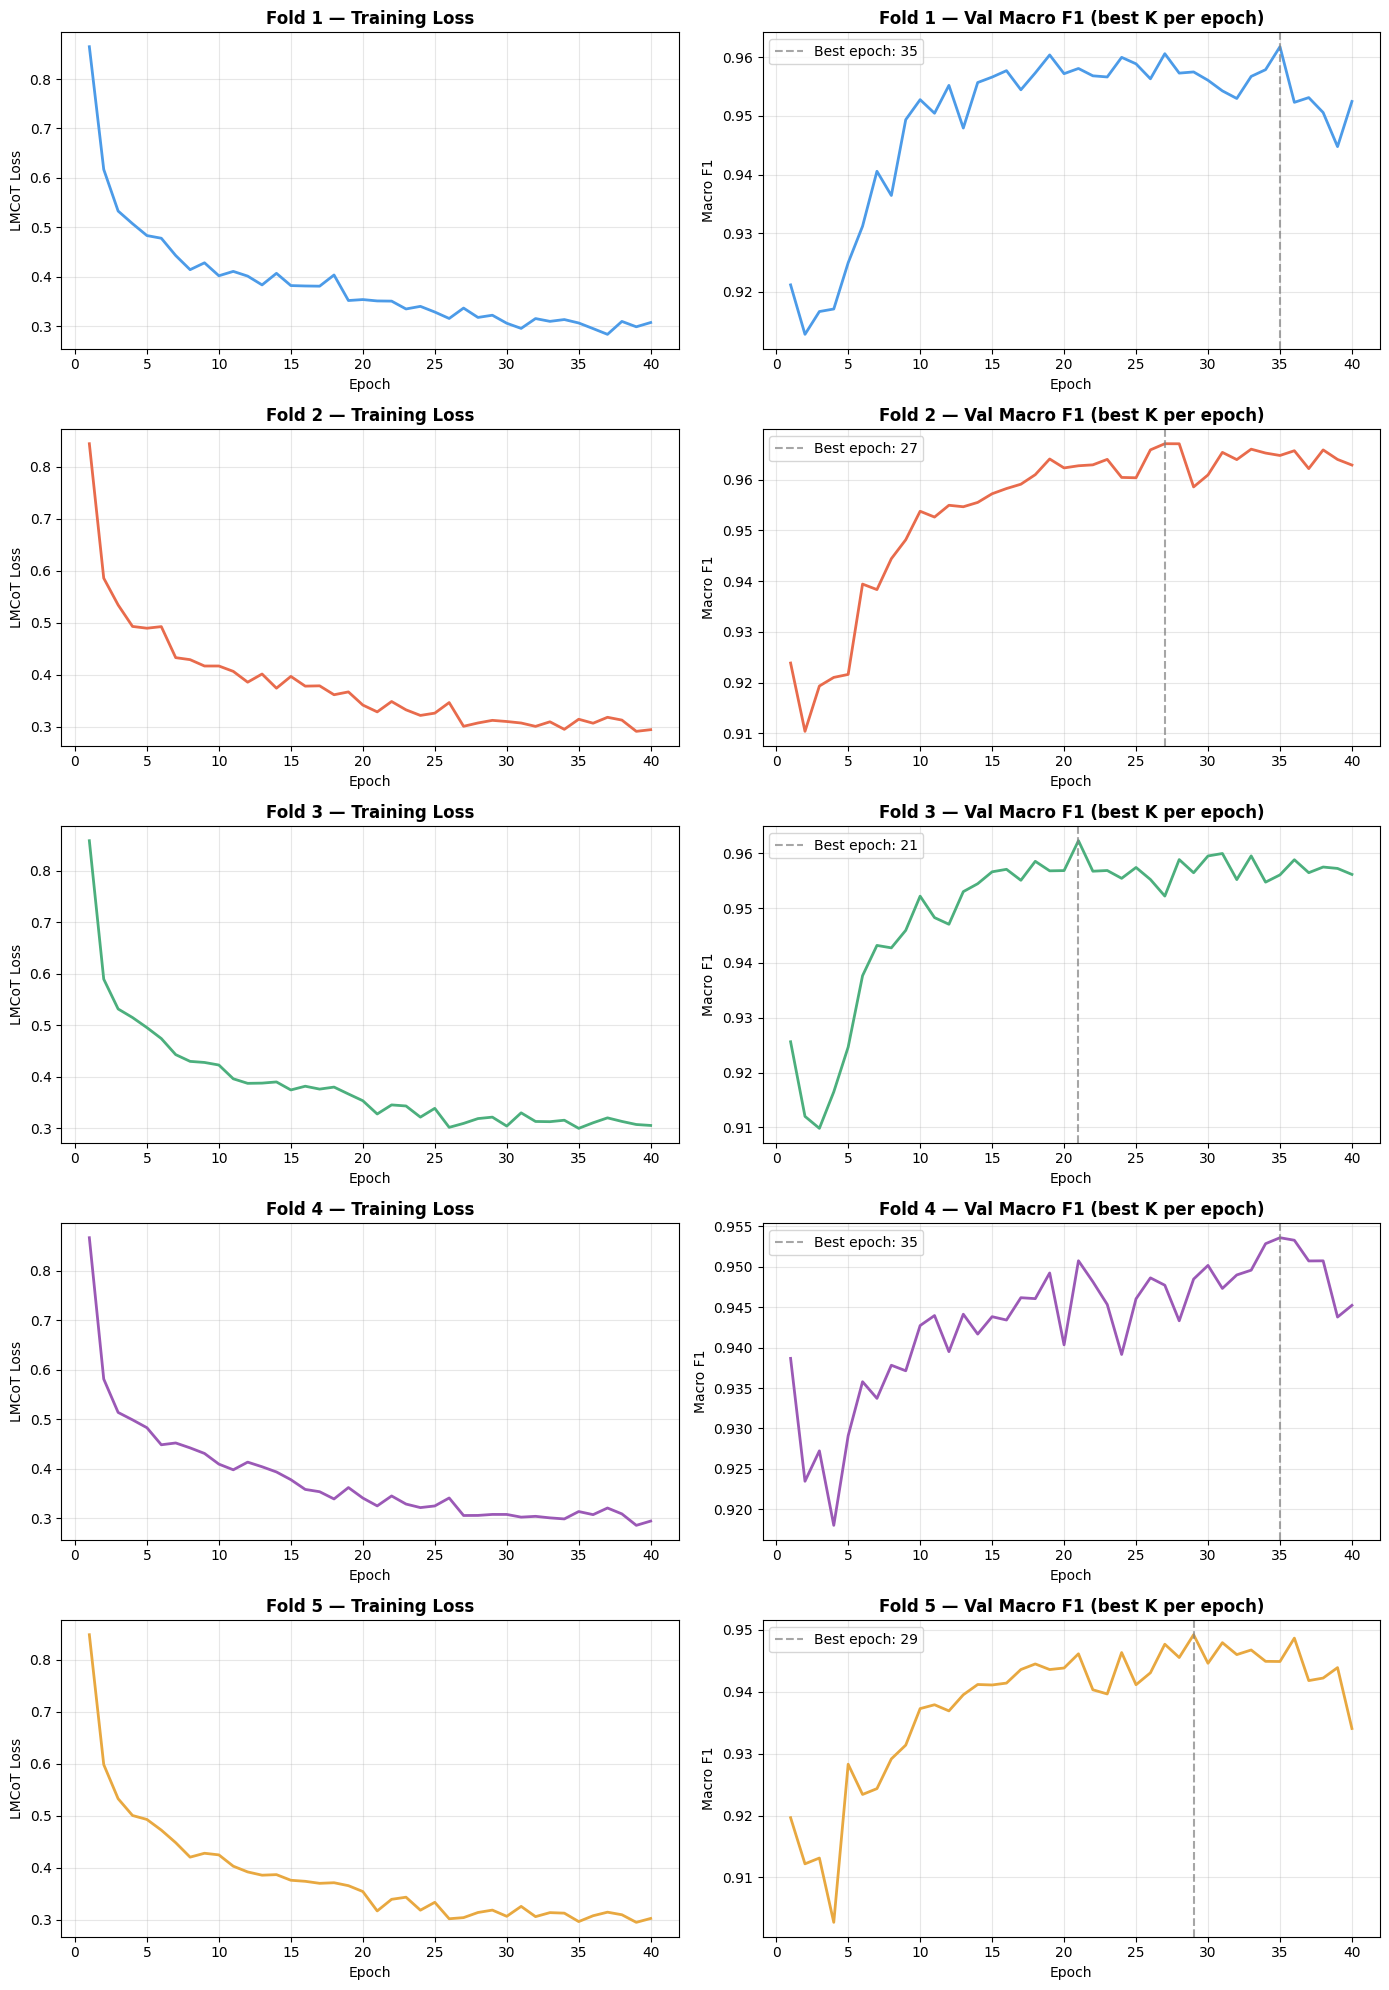

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Plot training curves for each fold
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(CFG.N_FOLDS, 2, figsize=(14, 4 * CFG.N_FOLDS))
colors = ["#4C9BE8", "#E86B4C", "#4CAF7D", "#9B59B6", "#E8A840"]

for i, r in enumerate(fold_results):
    hist   = r["history"]
    epochs = range(1, len(hist["train_loss"]) + 1)

    ax1 = axes[i, 0]
    ax1.plot(epochs, hist["train_loss"], color=colors[i], linewidth=2)
    ax1.set_title(f"Fold {r['fold']} — Training Loss", fontweight="bold")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("LMCoT Loss")
    ax1.grid(True, alpha=0.3)

    ax2 = axes[i, 1]
    ax2.plot(epochs, hist["val_macro_f1"], color=colors[i], linewidth=2)
    best_ep = int(np.argmax(hist["val_macro_f1"])) + 1
    ax2.axvline(best_ep, color="gray", linestyle="--", alpha=0.7, label=f"Best epoch: {best_ep}")
    ax2.set_title(f"Fold {r['fold']} — Val Macro F1 (best K per epoch)", fontweight="bold")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Macro F1")
    ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [22]:
# ── Evaluate best fold with XGBoost ─────────────────────────────────────────
skf2 = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
splits2 = list(skf2.split(df_train["img_path"], df_train["class_idx"]))
train_idx, val_idx = splits2[best_fold_idx]
train_df_best = df_train.iloc[train_idx].reset_index(drop=True)
val_df_best   = df_train.iloc[val_idx].reset_index(drop=True)

embed_train = DFUDataset(train_df_best, transform=val_transform)
embed_val   = DFUDataset(val_df_best,   transform=val_transform)
train_ldr   = DataLoader(embed_train, batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                          num_workers=CFG.NUM_WORKERS)
val_ldr     = DataLoader(embed_val,   batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                          num_workers=CFG.NUM_WORKERS)

train_embs, train_labels_xgb = extract_embeddings(best_model, train_ldr, CFG.DEVICE)
val_embs,   val_labels_xgb   = extract_embeddings(best_model, val_ldr,   CFG.DEVICE)

# Re-fit XGBoost on this fold's train set
counts_best = [(train_df_best.class_idx == c).sum() for c in range(CFG.NUM_CLASSES)]
_, xgb_final = xgb_evaluate(train_embs, train_labels_xgb, val_embs, val_labels_xgb)
val_preds    = xgb_final.predict(val_embs)
# Alias for downstream cells
val_labels_knn = val_labels_xgb

print("\n" + "="*60)
print("  CLASSIFICATION REPORT (Best Fold Val Set — XGBoost)")
print("="*60)
print(classification_report(val_labels_xgb, val_preds,
                              target_names=CFG.CLASSES, zero_division=0))

macro_f1 = f1_score(val_labels_xgb, val_preds, average="macro", zero_division=0)
print(f"  Macro F1: {macro_f1:.4f}")


Best fold: 2  |  Macro F1: 0.9671  |  K: 1


Extracting embeddings:   0%|          | 0/510 [00:00<?, ?it/s]

Extracting embeddings:   0%|          | 0/128 [00:00<?, ?it/s]


  CLASSIFICATION REPORT (Best Fold Val Set)
              precision    recall  f1-score   support

        none       0.93      0.96      0.94       511
   infection       0.96      0.92      0.94       511
   ischaemia       0.99      0.99      0.99       272
        both       0.99      1.00      0.99       745

    accuracy                           0.97      2039
   macro avg       0.97      0.97      0.97      2039
weighted avg       0.97      0.97      0.97      2039

  Macro F1: 0.9671


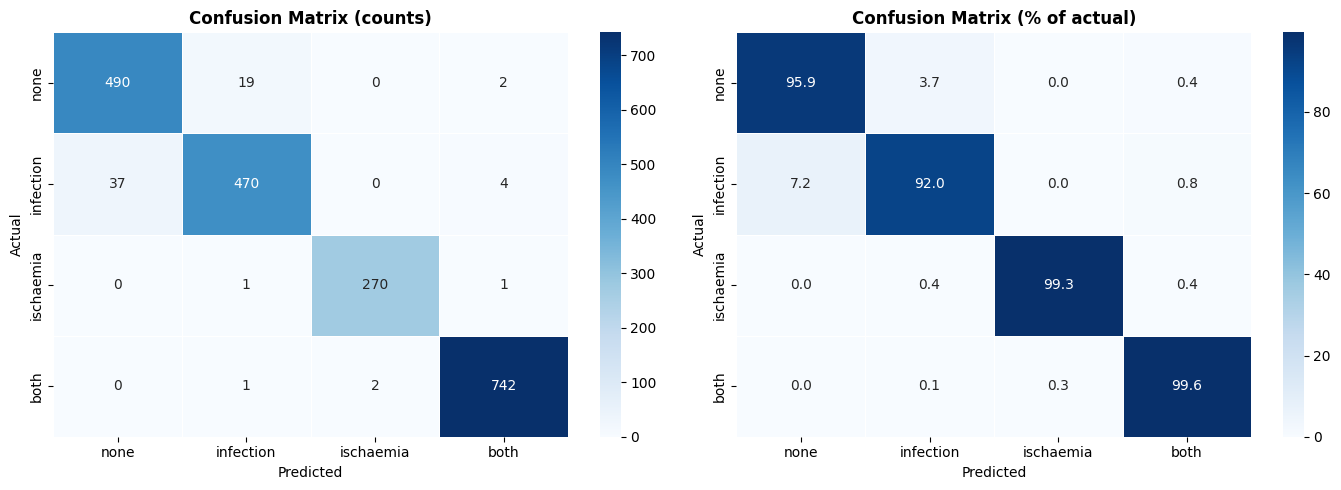

In [23]:
cm = confusion_matrix(val_labels_knn, val_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CFG.CLASSES, yticklabels=CFG.CLASSES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Confusion Matrix (counts)", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=CFG.CLASSES, yticklabels=CFG.CLASSES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title("Confusion Matrix (% of actual)", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


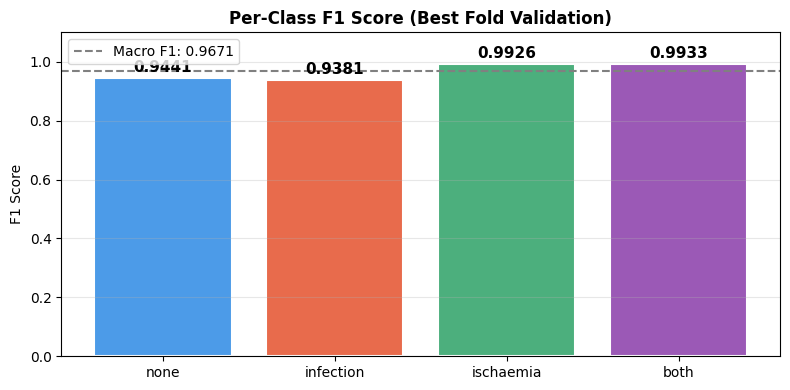

In [24]:
per_class_f1 = f1_score(val_labels_knn, val_preds,
                         average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4C9BE8", "#E86B4C", "#4CAF7D", "#9B59B6"]
bars = ax.bar(CFG.CLASSES, per_class_f1, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(macro_f1, color="gray", linestyle="--", linewidth=1.5, label=f"Macro F1: {macro_f1:.4f}")
ax.set_title("Per-Class F1 Score (Best Fold Validation)", fontweight="bold")
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.1)
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()


In [26]:
class TestDataset(Dataset):
    """Unlabelled test images."""
    def __init__(self, img_dir: str, transform):
        self.paths     = sorted(Path(img_dir).glob("*.jpg"))
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.paths[idx].name

@torch.no_grad()
def embed_test(model, img_dir, device):
    """Single-pass embedding of all test images."""
    model.eval()
    ds = TestDataset(img_dir, base_transform)
    dl = DataLoader(ds, batch_size=CFG.BATCH_SIZE * 2,
                    shuffle=False, num_workers=CFG.NUM_WORKERS)
    all_embs, all_names = [], []
    for imgs, img_names in tqdm(dl, desc="Embedding test images"):
        imgs = imgs.to(device)
        all_embs.append(model.embed(imgs).cpu().numpy())
        all_names.extend(img_names)
    return np.vstack(all_embs), all_names

print("Running inference on test set...")
test_embs, test_names = embed_test(best_model, CFG.TEST_IMG_DIR, CFG.DEVICE)

# XGBoost predict_proba
test_proba = xgb_final.predict_proba(test_embs)   # (N, 4)
test_preds = test_proba.argmax(axis=1)

df_submission = pd.DataFrame(
    test_proba, columns=["none", "infection", "ischaemia", "both"]
)
df_submission.insert(0, "image", test_names)
df_submission.to_csv("predictions.csv", index=False)
print(f"Saved predictions.csv  ({len(df_submission)} test images)")

assert df_submission[["none", "infection", "ischaemia", "both"]].sum(axis=1).between(0.999, 1.001).all(), \
    "Row probabilities do not sum to 1!"
print("Sanity check passed: all rows sum to 1.0 ✓")
print("\nSample submission rows:")
print(df_submission.head(3).to_string(index=False))
print("\nPrediction distribution:")
for i, cls in enumerate(CFG.CLASSES):
    n = (test_preds == i).sum()
    print(f"  {cls:12s}: {n:5d}  ({100*n/len(test_preds):.1f}%)")


Running inference on test set...


Embedding test images:   0%|          | 0/359 [00:00<?, ?it/s]

Saved predictions.csv  (5734 test images)
Sanity check passed: all rows sum to 1.0 ✓

Sample submission rows:
     image  none  infection  ischaemia  both
501000.jpg   0.0        1.0        0.0   0.0
501001.jpg   0.0        0.0        0.0   1.0
501002.jpg   0.0        1.0        0.0   0.0

Prediction distribution:
  none        :  3066  (53.5%)
  infection   :  1725  (30.1%)
  ischaemia   :   308  (5.4%)
  both        :   635  (11.1%)


In [ ]:
import pickle

save_payload = {
    "model_state_dict" : best_model.state_dict(),
    "fold"             : best_result["fold"],
    "macro_f1"         : best_result["best_macro_f1"],
    "train_embs"       : train_embs,
    "train_labels"     : train_labels_xgb,
    "config"           : {
        "img_size"   : CFG.IMG_SIZE,
        "classes"    : CFG.CLASSES,
        "shared_dim" : CFG.SHARED_DIM,
    }
}

torch.save(save_payload, os.path.join(CFG.SAVE_DIR, "best_model_final.pt"))

with open(os.path.join(CFG.SAVE_DIR, "xgb_classifier.pkl"), "wb") as f:
    pickle.dump(xgb_final, f)

print("Saved:")
print(f"  {CFG.SAVE_DIR}/best_model_final.pt")
print(f"  {CFG.SAVE_DIR}/xgb_classifier.pkl")
print(f"  predictions.csv")
print()
print("Training complete.")
print(f"Best Macro F1 (val): {best_result['best_macro_f1']:.4f}")


## How to load the model for later inference

```python
import torch, pickle
from models import SiameseNetwork, DFUDataset, val_transform, CFG

# Load
payload = torch.load("checkpoints/best_model_final.pt")
model   = SiameseNetwork().to(CFG.DEVICE)
model.load_state_dict(payload["model_state_dict"])
model.eval()

with open("checkpoints/xgb_classifier.pkl", "rb") as f:
    xgb_clf = pickle.load(f)

# Embed new image
from PIL import Image
img    = Image.open("your_image.jpg").convert("RGB")
tensor = val_transform(img).unsqueeze(0).to(CFG.DEVICE)
emb    = model.embed(tensor).cpu().numpy()   # (1, 512)

# Predict
pred_class = xgb_clf.predict(emb)[0]
proba      = xgb_clf.predict_proba(emb)[0]
print(CFG.CLASSES[pred_class], proba)
```


In [19]:
# ── Step 1 : Scan checkpoints and load whatever folds are available ───────────
import os, pickle
import numpy as np
import torch
from pathlib import Path

available_folds = []

for fold_idx in range(CFG.N_FOLDS):
    bp = os.path.join(CFG.SAVE_DIR, f"fold_{fold_idx}_best.pt")
    if os.path.exists(bp):
        ckpt = torch.load(bp, map_location=CFG.DEVICE, weights_only=False)
        available_folds.append({
            "fold_idx"   : fold_idx,
            "fold_num"   : fold_idx + 1,
            "xgb_model"  : ckpt.get("xgb_model"),
            "macro_f1"   : ckpt.get("macro_f1", 0.0),
            "state_dict" : ckpt["state_dict"],
        })
        print(f"  ✓ Fold {fold_idx+1} found  |  Macro F1: {ckpt.get('macro_f1', 0.0):.4f}")
    else:
        print(f"  ✗ Fold {fold_idx+1} not found — skipped")

assert len(available_folds) > 0, "No fold checkpoints found in checkpoints/."
print(f"\n{len(available_folds)} fold(s) available out of {CFG.N_FOLDS}")


  ✓ Fold 1 found  |  Macro F1: 0.9789  |  Best K: 1
  ✓ Fold 2 found  |  Macro F1: 0.9509  |  Best K: 1
  ✗ Fold 3 not found — skipped
  ✗ Fold 4 not found — skipped
  ✗ Fold 5 not found — skipped

2 fold(s) available out of 5


In [20]:
# ── Step 2 : Pick the best available fold and load its model ─────────────────
best_entry    = max(available_folds, key=lambda x: x["macro_f1"])
best_fold_idx = best_entry["fold_idx"]

print(f"Best available fold : Fold {best_entry['fold_num']}")
print(f"  Macro F1          : {best_entry['macro_f1']:.4f}")

best_model = SiameseNetwork().to(CFG.DEVICE)
best_model.load_state_dict(best_entry["state_dict"])
best_model.eval()
print("\nModel loaded and set to eval mode ✓")


Best available fold : Fold 1
  Macro F1          : 0.9789
  Best K            : 1
Loading facebook/dinov2-base from HuggingFace...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2 params — trainable: 28,359,168 / 86,580,480
Unfrozen blocks: 8..11 (last 4)

Model loaded and set to eval mode ✓


In [21]:
# ── Step 3 : Rebuild the train/val split for the best fold ───────────────────
#
# Recreates the exact same split used during training
# (same StratifiedKFold seed → deterministic).
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader

skf    = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.SEED)
splits = list(skf.split(df_train["img_path"], df_train["class_idx"]))

train_idx, val_idx = splits[best_fold_idx]
train_df_best = df_train.iloc[train_idx].reset_index(drop=True)
val_df_best   = df_train.iloc[val_idx].reset_index(drop=True)

print(f"Fold {best_entry['fold_num']} split rebuilt:")
print(f"  Train : {len(train_df_best)} images")
print(f"  Val   : {len(val_df_best)} images")

embed_train = DFUDataset(train_df_best, transform=base_transform)
embed_val   = DFUDataset(val_df_best,   transform=base_transform)

train_ldr = DataLoader(embed_train, batch_size=CFG.BATCH_SIZE * 2,
                        shuffle=False, num_workers=CFG.NUM_WORKERS)
val_ldr   = DataLoader(embed_val,   batch_size=CFG.BATCH_SIZE * 2,
                        shuffle=False, num_workers=CFG.NUM_WORKERS)

Fold 1 split rebuilt:
  Train : 12418 images
  Val   : 3105 images


In [22]:
# ── Step 4 : Extract embeddings and fit XGBoost ──────────────────────────────
print("Extracting train embeddings...")
train_embs, train_labels_xgb = extract_embeddings(best_model, train_ldr, CFG.DEVICE)

print("Extracting val embeddings...")
val_embs, val_labels_xgb = extract_embeddings(best_model, val_ldr, CFG.DEVICE)

print("Fitting XGBoost...")
macro_f1_xgb, xgb_final = xgb_evaluate(train_embs, train_labels_xgb,
                                         val_embs,   val_labels_xgb)
val_preds = xgb_final.predict(val_embs)
# Alias for downstream cells
val_labels_knn = val_labels_xgb
print(f"XGBoost fitted — Val Macro F1: {macro_f1_xgb:.4f} ✓")


Extracting train embeddings...


Extracting embeddings:   0%|          | 0/777 [00:00<?, ?it/s]

Extracting val embeddings...


Extracting embeddings:   0%|          | 0/195 [00:00<?, ?it/s]


Fitting KNN with K=1...
KNN fitted and val predictions ready ✓


In [23]:
# ── Step 5 : Classification report ───────────────────────────────────────────
from sklearn.metrics import f1_score, classification_report

macro_f1 = f1_score(val_labels_xgb, val_preds, average="macro", zero_division=0)

print(f"{'='*60}")
print(f"  CLASSIFICATION REPORT — Fold {best_entry['fold_num']} Val Set  (XGBoost)")
if len(available_folds) < CFG.N_FOLDS:
    print(f"  ⚠️  Only {len(available_folds)}/{CFG.N_FOLDS} folds completed")
print(f"{'='*60}")
print(classification_report(val_labels_xgb, val_preds,
                              target_names=CFG.CLASSES, zero_division=0))
print(f"  Macro F1 : {macro_f1:.4f}")


  CLASSIFICATION REPORT — Fold 1 Val Set
  ⚠️  Only 2/5 folds completed
              precision    recall  f1-score   support

        none       0.98      0.98      0.98      1337
   infection       0.97      0.98      0.98      1326
   ischaemia       0.97      0.99      0.98       117
        both       0.98      0.97      0.98       325

    accuracy                           0.98      3105
   macro avg       0.98      0.98      0.98      3105
weighted avg       0.98      0.98      0.98      3105

  Macro F1 : 0.9789


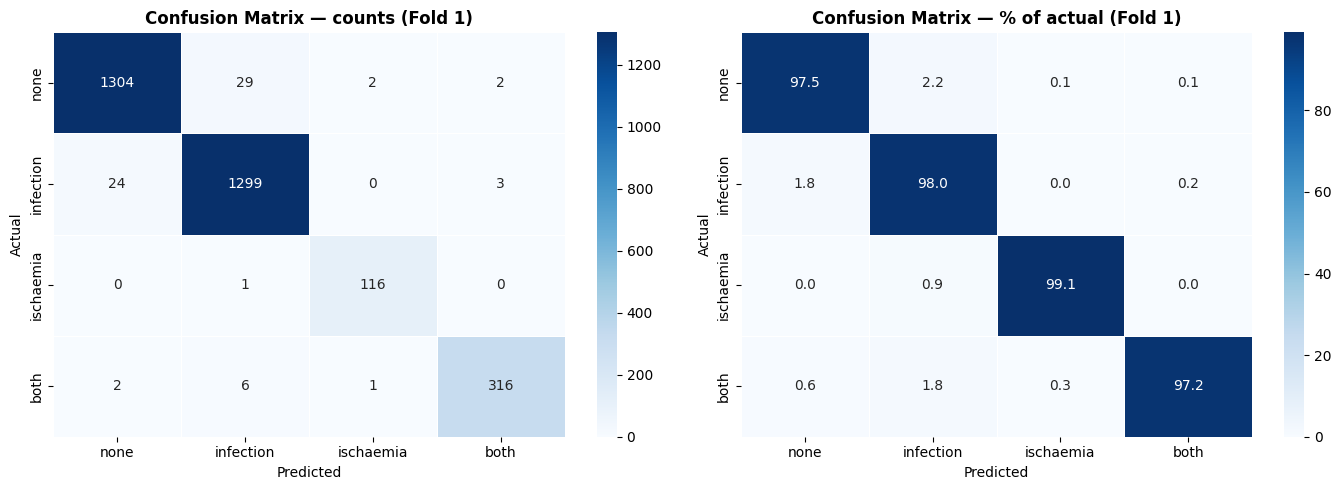

In [24]:
# ── Step 6 : Confusion matrix ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm     = confusion_matrix(val_labels_knn, val_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CFG.CLASSES, yticklabels=CFG.CLASSES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f"Confusion Matrix — counts (Fold {best_entry['fold_num']})",
                   fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=CFG.CLASSES, yticklabels=CFG.CLASSES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title(f"Confusion Matrix — % of actual (Fold {best_entry['fold_num']})",
                   fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

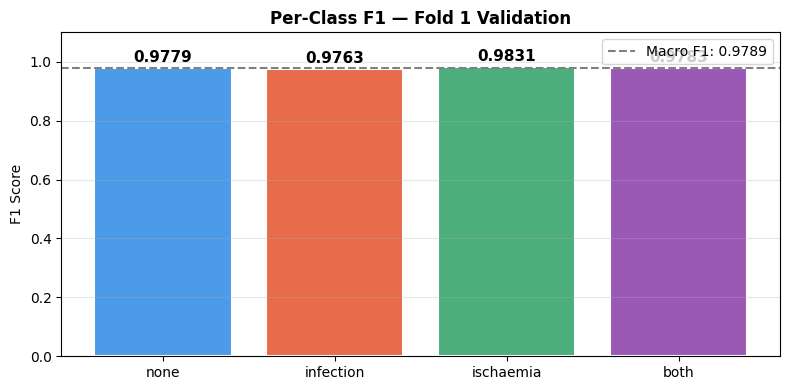

In [25]:
# ── Step 7 : Per-class F1 bar chart ──────────────────────────────────────────
per_class_f1 = f1_score(val_labels_knn, val_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(8, 4))
colors  = ["#4C9BE8", "#E86B4C", "#4CAF7D", "#9B59B6"]
bars    = ax.bar(CFG.CLASSES, per_class_f1, color=colors,
                  edgecolor="white", linewidth=1.5)
ax.axhline(macro_f1, color="gray", linestyle="--",
            linewidth=1.5, label=f"Macro F1: {macro_f1:.4f}")
ax.set_title(f"Per-Class F1 — Fold {best_entry['fold_num']} Validation",
              fontweight="bold")
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.1)
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# ── Step 8 : Inference on test set ───────────────────────────────────────────
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import pandas as pd

class TestDataset(Dataset):
    def __init__(self, img_dir, transform):
        self.paths     = sorted(Path(img_dir).glob("*.jpg"))
        self.transform = transform
    def __len__(self):  return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.paths[idx].name

@torch.no_grad()
def embed_test(model, img_dir, device):
    model.eval()
    ds = TestDataset(img_dir, base_transform)
    dl = DataLoader(ds, batch_size=CFG.BATCH_SIZE * 2,
                    shuffle=False, num_workers=CFG.NUM_WORKERS)
    all_embs, all_names = [], []
    for imgs, names in tqdm(dl, desc="Embedding test images"):
        imgs = imgs.to(device)
        all_embs.append(model.embed(imgs).cpu().numpy())
        all_names.extend(names)
    return np.vstack(all_embs), all_names

print("Running inference on test set...")
test_embs, test_names = embed_test(best_model, CFG.TEST_IMG_DIR, CFG.DEVICE)

test_proba = xgb_final.predict_proba(test_embs)   # (N, 4)
test_preds = test_proba.argmax(axis=1)

df_submission = pd.DataFrame(test_proba, columns=["none", "infection", "ischaemia", "both"])
df_submission.insert(0, "image", test_names)
df_submission.to_csv("predictions.csv", index=False)

print(f"Saved predictions.csv ({len(df_submission)} test images)")
print("\nPrediction distribution:")
for i, cls in enumerate(CFG.CLASSES):
    n = (test_preds == i).sum()
    print(f"  {cls:12s}: {n:5d}  ({100*n/len(test_preds):.1f}%)")
print("\nSample rows:")
print(df_submission.head(3).to_string(index=False))


Running inference on test set...


Embedding test images:   0%|          | 0/359 [00:00<?, ?it/s]

Saved predictions.csv (5734 test images)

Prediction distribution:
  none        :  3015  (52.6%)
  infection   :  1893  (33.0%)
  ischaemia   :   338  (5.9%)
  both        :   488  (8.5%)

Sample rows:
     image  none  infection  ischaemia  both
501000.jpg   0.0        1.0        0.0   0.0
501001.jpg   0.0        0.0        0.0   1.0
501002.jpg   0.0        1.0        0.0   0.0


In [ ]:
# ── Step 9 : Save model + XGBoost to disk for later use ─────────────────────
import pickle

save_payload = {
    "model_state_dict" : best_model.state_dict(),
    "fold"             : best_entry["fold_num"],
    "macro_f1"         : best_entry["macro_f1"],
    "train_embs"       : train_embs,
    "train_labels"     : train_labels_xgb,
    "config"           : {
        "img_size"   : CFG.IMG_SIZE,
        "classes"    : CFG.CLASSES,
        "shared_dim" : CFG.SHARED_DIM,
    }
}

torch.save(save_payload, os.path.join(CFG.SAVE_DIR, "best_model_final.pt"))

with open(os.path.join(CFG.SAVE_DIR, "xgb_classifier.pkl"), "wb") as f:
    pickle.dump(xgb_final, f)

print(f"Saved  checkpoints/best_model_final.pt")
print(f"Saved  checkpoints/xgb_classifier.pkl")
print(f"Saved  predictions.csv")
print(f"\nBest Macro F1 : {best_entry['macro_f1']:.4f}  (Fold {best_entry['fold_num']})")
